# Midterm Exam Take Home (Modeling) Portion

**Jaren Figueiredo**

After the Kaggle Playground Series S6C4 ended, I read some of the writeups, and the top performers seemed to just create a large ensemble of a bunch of different models (50+), a lot of them xgboost.  I want to replicate this, so I will probably create around a bunch of models and ensemble them to see if my predictive power improves.  Due to class imbalance, I will target `balanced_accuracy` as my scoring metric.

## Imports and set up

In [32]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [81]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import StackingClassifier

from xgboost import XGBClassifier

In [34]:
TRAIN_DATA_PATH = "./Data/midterm_train.csv"
TEST_DATA_PATH = "./Data/midterm_test.csv"

In [35]:
df = pd.read_csv(TRAIN_DATA_PATH)
df.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,286,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,2,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,1,999,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,213,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,845,1,7,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


In [36]:
X = df.drop(["id", "accepted_offer"], axis=1)
y = df['accepted_offer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

## EDA

*"Focus on insights that influenced your modeling."*

In [37]:
df.select_dtypes("str").describe()

,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,prior_outcome_status
count,32950,32950,32950,32950,32950,32950,32950,32950,32950
unique,12,4,8,3,3,3,10,5,3
top,admin.,married,university.degree,no,yes,no,may,thu,nonexistent
freq,8336,19889,9772,26089,17291,27168,10980,6893,28452


The max categories for the categorical variables is 12, so one-hot encoding will probably suffice compared to target encoding.  The only place I see for potentially ordinal encoding is `education_background`; I will likely include both encoding methods for my ensemble.

In [38]:
df["accepted_offer"].value_counts() # Large target class imbalance

accepted_offer
0    29235
1     3715
Name: count, dtype: int64

I must preserve class performance due to class imbalance

In [39]:
print("Null observations by variable:")
df.isna().sum() 

Null observations by variable:


id                           0
customer_age                 0
occupation_type              0
relationship_status          0
education_background         0
has_credit_issue             0
mortgage_status              0
personal_loan_status         0
last_contact_month           0
day_of_week                  0
contact_time_minutes         0
contact_attempt_count        0
days_since_prior_contact     0
prior_contact_count          0
prior_outcome_status         0
economic_activity_change     0
consumer_price_index         0
consumer_confidence_index    0
reference_interest_rate      0
employment_level_index       0
accepted_offer               0
is_repeat_customer           0
recent_contact_flag          0
dtype: int64

As expected, this dataset is extremely clean.  Let's look at feature correlations:

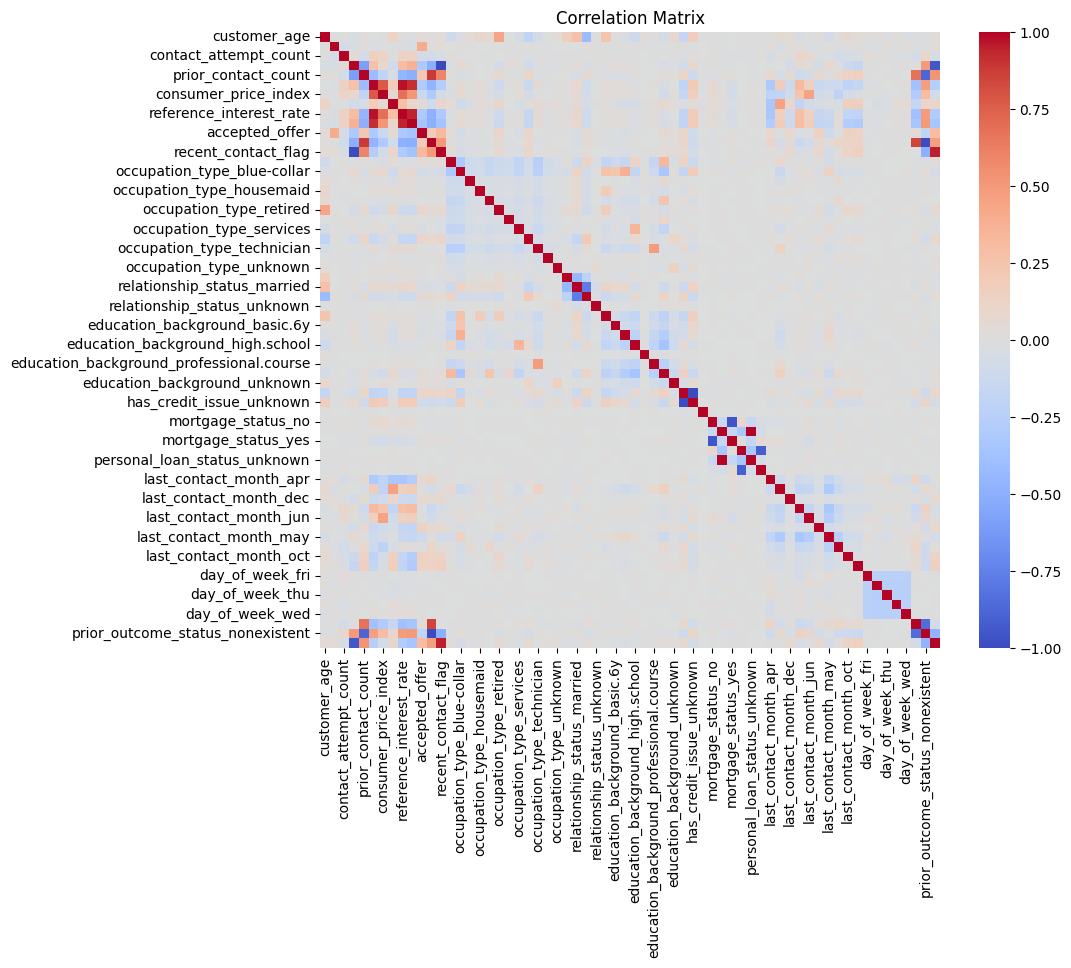

In [40]:
df_enc = pd.get_dummies(df.drop(["id"], axis=1), columns=df.select_dtypes("str").columns)
corr = df_enc.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0)

plt.title("Correlation Matrix")
plt.show()

In [41]:
df_enc = pd.get_dummies(df.drop(["id"], axis=1), columns=df.select_dtypes("str").columns, drop_first=True)
corr = df_enc.corr()

corr_long = (
    corr
      .reset_index()
      .melt(id_vars="index", var_name="variable_2", value_name="correlation")
      .rename(columns={"index": "variable_1"})
)
corr_long = corr_long[corr_long["variable_1"] != corr_long["variable_2"]]
corr_long["abs_corr"] = np.abs(corr_long["correlation"])
corr_long.sort_values("abs_corr", ascending=False).head(10)

,variable_1,variable_2,correlation,abs_corr
2126,mortgage_status_unknown,personal_loan_status_unknown,1.000000,1.000000
2018,personal_loan_status_unknown,mortgage_status_unknown,1.000000,1.000000
2926,is_repeat_customer,prior_outcome_status_nonexistent,-1.000000,1.000000
658,prior_outcome_status_nonexistent,is_repeat_customer,-1.000000,1.000000
177,recent_contact_flag,days_since_prior_contact,-0.999993,0.999993
663,days_since_prior_contact,recent_contact_flag,-0.999993,0.999993
283,reference_interest_rate,economic_activity_change,0.972189,0.972189
445,economic_activity_change,reference_interest_rate,0.972189,0.972189
219,prior_outcome_status_success,days_since_prior_contact,-0.950592,0.950592
2973,days_since_prior_contact,prior_outcome_status_success,-0.950592,0.950592


There exists perfect multicollinearity for even non-binary variables, meaning that our estimators will be biased, and aggressive feature selection can simplify our modeling without losing predictive power.

In [42]:
df_enc.corr()["accepted_offer"].sort_values(ascending=False)

accepted_offer                              1.000000
contact_time_minutes                        0.404403
recent_contact_flag                         0.319990
prior_outcome_status_success                0.310693
prior_contact_count                         0.229570
is_repeat_customer                          0.191969
last_contact_month_mar                      0.146823
last_contact_month_oct                      0.134087
last_contact_month_sep                      0.130396
occupation_type_retired                     0.095869
occupation_type_student                     0.095549
last_contact_month_dec                      0.076328
relationship_status_single                  0.054397
education_background_university.degree      0.052992
consumer_confidence_index                   0.050504
customer_age                                0.031586
education_background_unknown                0.023965
day_of_week_thu                             0.014353
occupation_type_unemployed                  0.

The target variable `accepted_offer` is correlated with multiple individual features, meaning that even something simple like a linear regression may explain the target variability; I will include a linear regression in my ensemble as a result.

## Feature engineering/selection

### LOFO importances

In [43]:
df_lofo = df.copy()

str_cols = df_lofo.select_dtypes(include=["object", "string"]).columns

# Convert "str" columns to categorical for xgboost
df_lofo[str_cols] = df_lofo[str_cols].astype("category")

X_lofo = df_lofo.drop(["id", "accepted_offer"], axis=1)
y_lofo = df_lofo["accepted_offer"]

In [44]:
X_train_lofo, X_test_lofo, y_train_lofo, y_test_lofo = train_test_split(X_lofo, y_lofo, test_size=.2, random_state=42)

In [45]:
f1_class_0 = make_scorer(f1_score, pos_label=0)

model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    enable_categorical=True,
    random_state=42,
    device="cuda",
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

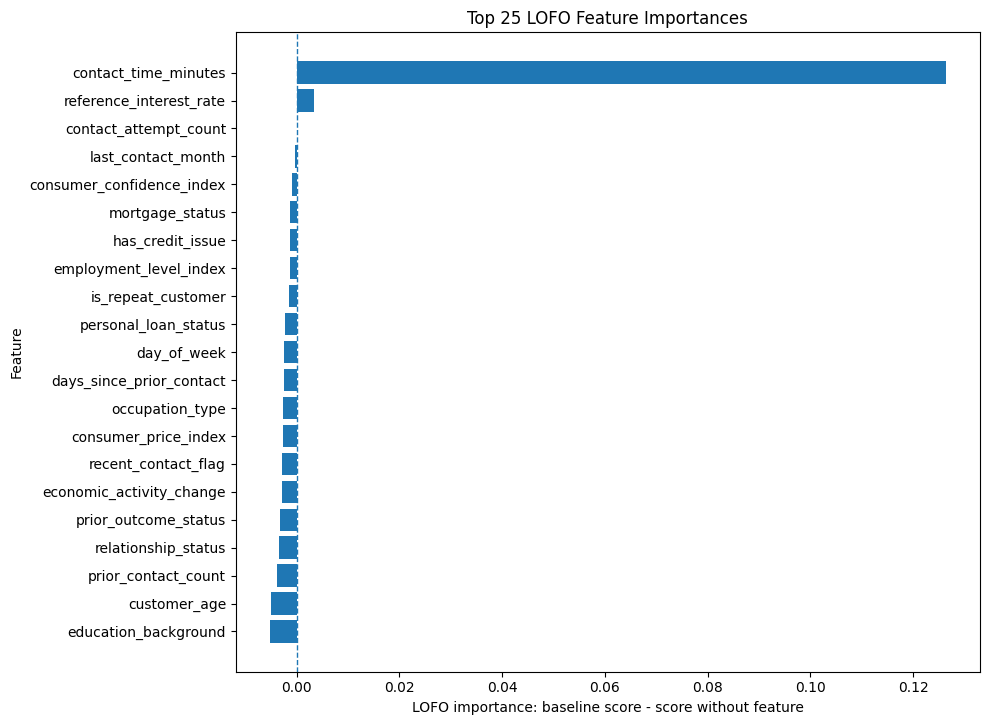

In [46]:
def lofo_importance(
    estimator,
    X,
    y,
    scoring,
    cv,
    features=None,
    n_jobs=None
):
    """
    Leave-One-Feature-Out importance.

    Importance = baseline CV score - CV score after dropping feature.

    Positive importance:
        Dropping the feature made performance worse, so the feature helped.

    Negative importance:
        Dropping the feature improved performance, so the feature may be noisy,
        redundant, or harmful under this model/metric.
    """
    if features is None:
        features = list(X.columns)

    baseline_scores = cross_val_score(
        clone(estimator),
        X[features],
        y,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs
    )

    baseline_mean = baseline_scores.mean()
    baseline_std = baseline_scores.std()

    rows = []

    for feature in features:
        remaining_features = [f for f in features if f != feature]

        dropped_scores = cross_val_score(
            clone(estimator),
            X[remaining_features],
            y,
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs
        )

        dropped_mean = dropped_scores.mean()
        dropped_std = dropped_scores.std()

        rows.append({
            "feature": feature,
            "baseline_score": baseline_mean,
            "score_without_feature": dropped_mean,
            "importance": baseline_mean - dropped_mean,
            "baseline_std": baseline_std,
            "score_without_feature_std": dropped_std
        })

    result = pd.DataFrame(rows)
    result = result.sort_values("importance", ascending=False).reset_index(drop=True)

    return result


lofo_df = lofo_importance(
    estimator=model,
    X=X_train_lofo,
    y=y_train_lofo,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

lofo_df.head(20)


def plot_lofo_importance(lofo_df, top_n=30):
    plot_df = lofo_df.head(top_n).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, max(5, 0.35 * len(plot_df))))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("LOFO importance: baseline score - score without feature")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} LOFO Feature Importances")
    plt.tight_layout()
    plt.show()

plot_lofo_importance(lofo_df, top_n=25)

`contact_time_minutes` had the highest correlation with `accepted_offer`, so it's unsurprising that it has high explanatory power.  I am surprised that every other feature importance except for `reference_interest_rate` was negative.

### SAGE (Shapley Additive Global Importance)

SAGE is a shapley value derivative measure that estimates a features contribution to the overall log-loss of the model - how much the model got better due to a feature's presence.

In [47]:
model = model.fit(X_train_lofo, y_train_lofo)

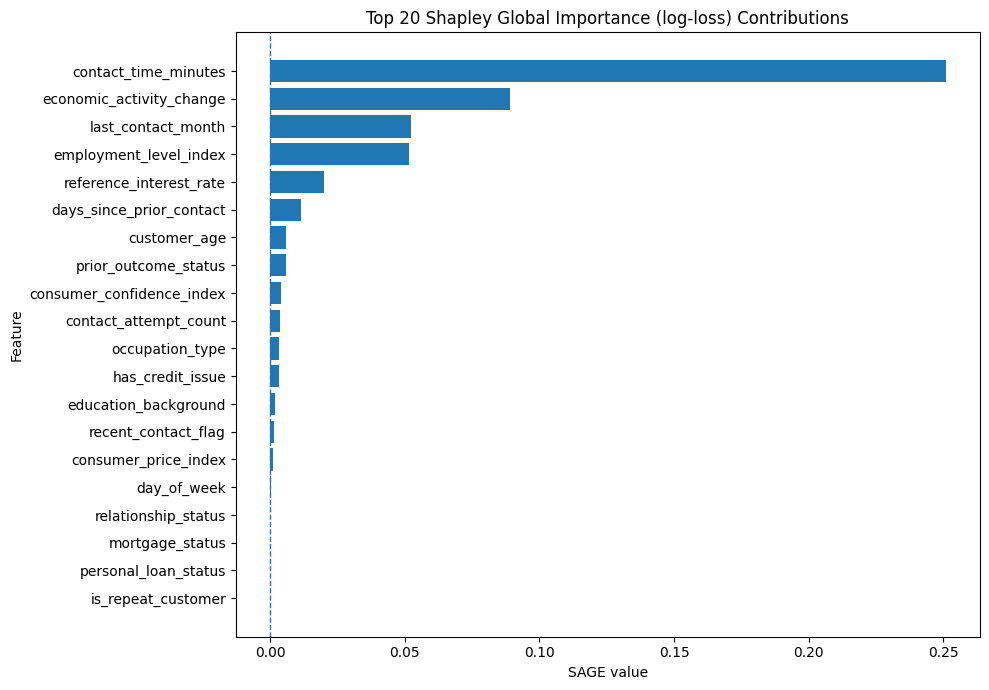

In [48]:
from sage import estimate_sage_importance, plot_sage_importance

# Sample from data to reduce computation
X_eval = X_test_lofo.sample(min(2000, len(X_test_lofo)), random_state=42)
y_eval = y_test_lofo.loc[X_eval.index]

X_background = X_train.sample(min(1000, len(X_train_lofo)), random_state=42)

sage_df = estimate_sage_importance(
    model=model,
    X_eval=X_eval,
    y_eval=y_eval,
    X_background=X_background,
    n_permutations=100,
    batch_size=256,
    random_state=42
)

plot_sage_importance(sage_df)

The plot exhibits similar findings as the LOFO plot - `contact_time_minutes` improves the model most, and all other features are far behind.

### Lasso regression

In [49]:
from lasso import fit_lasso_feature_screen, plot_lasso_coefficients

lasso_results = fit_lasso_feature_screen(X_train_lofo, y_train_lofo)

lasso_model = lasso_results["model"]
lasso_coef_df = lasso_results["coef_df"]
lasso_feature_summary = lasso_results["feature_summary"]
nonzero_lasso_features = lasso_results["nonzero_features"]
positive_lasso_features = lasso_results["positive_features"]

print(f"Chosen alpha: {lasso_results['alpha']:.6g}")
print(f"Nonzero encoded coefficients: {lasso_results['n_nonzero_encoded']} of {lasso_results['n_encoded_features']}")
print(f"Nonzero source features: {len(nonzero_lasso_features)} of {X_train_lofo.shape[1]}")
print(f"Positive source features for Shapley-Lorenz: {len(positive_lasso_features)}")

Chosen alpha: 0.000127764
Nonzero encoded coefficients: 40 of 63
Nonzero source features: 17 of 21
Positive source features for Shapley-Lorenz: 11


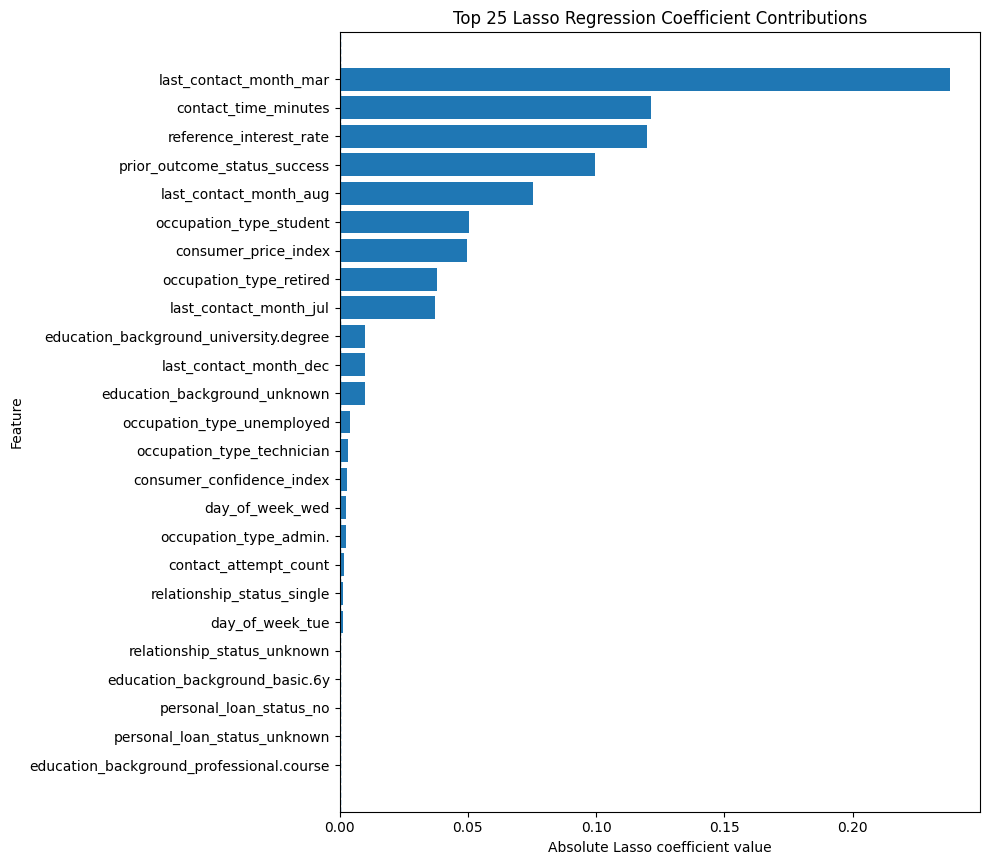

In [50]:
plot_lasso_coefficients(lasso_coef_df, top_n=25)

A Lasso regression found an interesting result: `last_contact_month_mar` is doing a lot of the heavy lifting.  Let's check the LASSO model's performance to see if it is performing well, indicating that `last_contact_month` is indeed contributing to the model's predictive power.

In [61]:
lasso_model_preds = lasso_model.predict(X_test_lofo)
best_threshold = {}
for threshold in np.linspace(.05, .95, 19):
    lasso_model_preds_threshold = np.where(lasso_model_preds > threshold, 1, 0)
    threshold_balanced_accuracy = balanced_accuracy_score(y_test_lofo, lasso_model_preds_threshold)
    best_threshold[threshold] = threshold_balanced_accuracy
best_threshold = max(best_threshold, key=best_threshold.get)
print(best_threshold)
lasso_model_preds = np.where(lasso_model_preds > best_threshold, 1, 0)
print(f"Lasso test balanced accuracy: {balanced_accuracy_score(y_test_lofo, lasso_model_preds)}")

0.15
Lasso test balanced accuracy: 0.8745448578452488


After model tuning, the balanced accuracy is quite good, indicating that `last_contact_month` may be explaining part of the model.  We can dig in deeper with the below Shapley Lorenz values, which are trained on the features with non-zero LASSO coefficients.

### Shapley-Lorenz values

The Shapley Lorenz computation has $$O(n^2)$$ time complexity, where n is the number of features.  This dataset has 21 features, which I why I am using the non-zero LASSO coefficients for the Shapley Lorenz calculation.

In [62]:
from shapley_lorenz import estimate_shapley_lorenz_importance, plot_shapley_lorenz

In [63]:
slz_results = estimate_shapley_lorenz_importance(
    base_model=model,
    X_train=X_train_lofo,
    y_train=y_train_lofo,
    X_eval_source=X_test_lofo,
    y_eval_source=y_test_lofo,
    features=positive_lasso_features,
    background_n=30,
    eval_n=30,
    n_iter=250,
    random_state=42,
)

slz_df = slz_results["importance"]
slz_values = slz_results["raw_values"]
slz_model = slz_results["model"]
feature_names = slz_results["features"]

slz_df

100%|██████████| 11/11 [07:48<00:00, 42.61s/it]


,feature,shapley_lorenz_value
0,contact_time_minutes,0.165060
1,reference_interest_rate,0.114927
2,last_contact_month,0.101210
3,prior_outcome_status,0.029286
4,consumer_price_index,0.007754
5,consumer_confidence_index,0.006588
6,contact_attempt_count,0.005717
7,education_background,0.005077
8,occupation_type,0.003205
9,day_of_week,0.000657


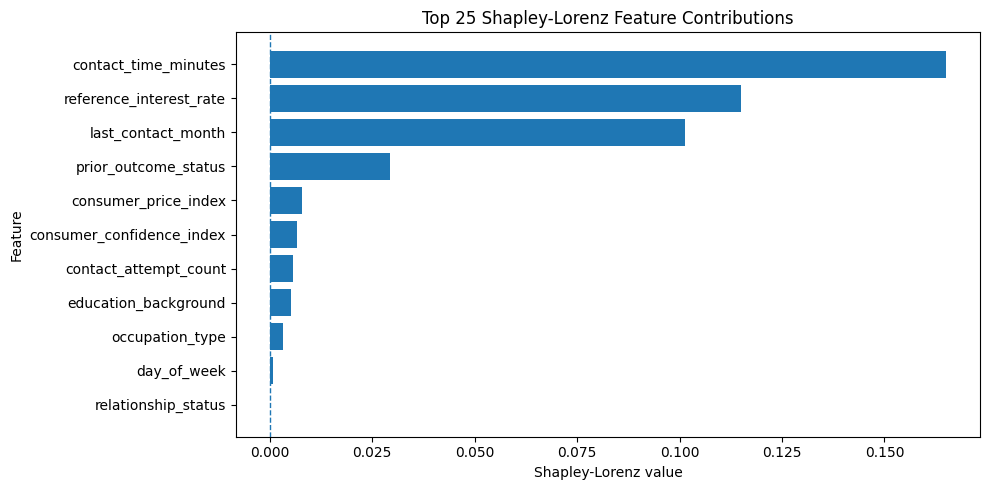

In [64]:
plot_shapley_lorenz(slz_df, top_n=25)

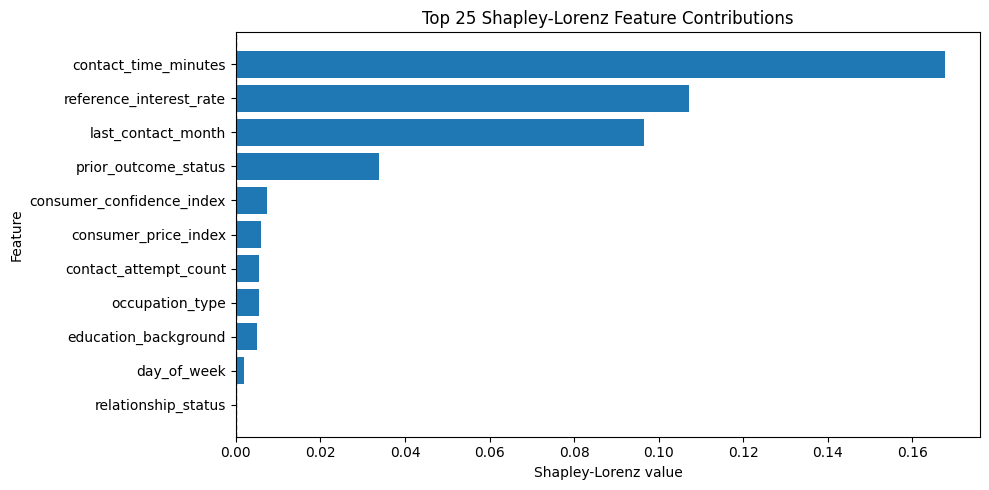

While `contact_time_minutes` is the top explainer for Shapley-Lorenz values, `last_contact_month` is the 3rd most important feature.  Unlike LOFO, SAGE, and Shapley-Lorenz, the LASSO regression coefficients were broken down into each feature value possibility, indicating that while not all months are that important for prediction `accepted_loan`, times where the `last_contact_month` was March is very important for predicting `accepted_loan`.

### Comparing Feature Selection Plots

For all feature selection methods except for LASSO regression, `contact_time_minutes` was the most important feature.  Other features that consistently show up are `last_contact_month` and `reference_interest_rate`. Another feature that seems to offer some explanatory power is `prior_outcome_status`.  Because this is not an econometrics class, I don't need to worry about explainability.  Some of the models in my ensemble will use only these 4 features, and some of the models in my ensemble will use all of the features.

## Dataset preparation

Since I want to create a large ensemble, I am using AI to help me structure the code (there were no instructions about not using AI for the takehome portion).  Models in use are:
1. `XGBClassifier()`
2. `CatBoostClassifier()`
3. `ExtraTreesClassifier()`
4. `GaussianNB()`
5. `LinearRegression()`
6. `LogisticRegression()`
7. `Lasso()`

There are a "zoo" of models being fit (132 intermediate models, so I moved the code to a helper function `ensemble_helpers.py` to reduct the amount of code here).  The dataset preparation done:
1. Use `contact_time_minutes`, `last_contact_month`, `reference_interest_rate`, and `prior_outcome_status` as the sole features, so each model will have a version will all features and a version with only these 4 features.
2. Create interaction features (polynomial features), which were used as possibilities for non-tree models.
3. Ordinally encode `education_background` (each model gets 2 versions)
4. Create 3 sampling techniques: undersample, oversample, and leave as-is.
5. For `XGBClassifier()`, there are 3 versions, 1 where the scoring metric is f1_class_1, another where the scoring metric is f1_class_0, and a final tuned on `f1_macro`, which should create model specialists.
6. `ExtraTreesClassifier()`, `GaussianNB()`, `LinearRegression()`, and `Lasso()` are tuned on `balanced_accuracy`.
7. `CatBoostClassifier()` has a version tuned on `balanced_accuracy` and a version tuned on `f1_macro`.

| Model Type | # of models to be trained |
| -------- | -------- |
| XGBoost | 18 |
| CatBoost | 12 |
| Extra Trees | 6 |
| Naive Bayes | 24 |
| Linear Regression | 24 |
| Logistic Regression | 24 |
| Lasso Regression | 24 |

In [67]:
import importlib
import ensemble_helpers
importlib.reload(ensemble_helpers)

from ensemble_helpers import (
    FOCUSED_FEATURES,
    build_model_specs,
    fit_model_zoo,
    print_metric_report,
)

ensemble_feature_sets = {
    "all": list(X_train_lofo.columns),
    "focused": [col for col in FOCUSED_FEATURES if col in X_train_lofo.columns],
}

model_zoo_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

model_specs = build_model_specs(
    X_train_lofo,
    y=y_train_lofo,
    feature_sets=ensemble_feature_sets,
    random_state=42,
)

print(f"Focused feature set: {ensemble_feature_sets['focused']}")
print(f"Model specs to fit: {len(model_specs)}")

Focused feature set: ['contact_time_minutes', 'last_contact_month', 'reference_interest_rate', 'prior_outcome_status']
Model specs to fit: 132


## Modeling and evaluation

In [68]:
MAX_MODEL_ZOO_MODELS = None  # Set to a small number while testing, then None for the full zoo.

model_results, model_summary, stacking_estimators = fit_model_zoo(
    specs=model_specs,
    X_train=X_train_lofo,
    y_train=y_train_lofo,
    X_test=X_test_lofo,
    y_test=y_test_lofo,
    cv=model_zoo_cv,
    n_jobs=1,
    verbose=True,
    max_models=MAX_MODEL_ZOO_MODELS,
)

print(f"Fitted models stored for stacking: {len(stacking_estimators)}")
model_summary.sort_values("test_f1_class_1", ascending=False)[[
    "name",
    "family",
    "best_cv_score",
    "train_f1_class_1",
    "test_f1_class_1",
    "train_precision_class_1",
    "test_precision_class_1",
    "train_recall_class_1",
    "test_recall_class_1",
    "best_params",
]].head(25)

[001/132] xgb_f1_class_0_all_none | cv=0.9528 | train_f1_class_0=0.9574 | test_f1_class_0=0.9554
[002/132] xgb_f1_class_1_all_none | cv=0.6448 | train_f1_class_1=0.6755 | test_f1_class_1=0.6565
[003/132] xgb_f1_macro_all_none | cv=0.7990 | train_f1_macro=0.8090 | test_f1_macro=0.7983
[004/132] extra_trees_all_none | cv=0.7599 | train_balanced_accuracy=0.7634 | test_balanced_accuracy=0.7640
[005/132] catboost_balanced_accuracy_all_none | cv=0.8910 | train_balanced_accuracy=0.9071 | test_balanced_accuracy=0.8942
[006/132] catboost_f1_macro_all_none | cv=0.7941 | train_f1_macro=0.8101 | test_f1_macro=0.7991
[007/132] xgb_f1_class_0_all_undersample | cv=0.9142 | train_f1_class_0=0.9165 | test_f1_class_0=0.9160
[008/132] xgb_f1_class_1_all_undersample | cv=0.5941 | train_f1_class_1=0.6007 | test_f1_class_1=0.5905
[009/132] xgb_f1_macro_all_undersample | cv=0.7706 | train_f1_macro=0.7758 | test_f1_macro=0.7684
[010/132] extra_trees_all_undersample | cv=0.8608 | train_balanced_accuracy=0.9335

c:\Users\jfigg\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.009e+01, tolerance: 7.793e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\jfigg\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.101e+02, tolerance: 7.794e+00
  model = cd_fast.enet_coordinate_descent(


[084/132] lasso_regression_all_oversample_poly_edu_ordinal | cv=0.8559 | train_balanced_accuracy=0.8572 | test_balanced_accuracy=0.8647
[085/132] naive_bayes_focused_none_linear_edu_onehot | cv=0.6807 | train_recall_macro=0.6809 | test_recall_macro=0.6801
[086/132] linear_regression_focused_none_linear_edu_onehot | cv=0.6376 | train_precision_macro=0.7918 | test_precision_macro=0.8021
[087/132] logistic_regression_focused_none_linear_edu_onehot | cv=0.6846 | train_f1_macro=0.7211 | test_f1_macro=0.7154
[088/132] lasso_regression_focused_none_linear_edu_onehot | cv=0.6321 | train_balanced_accuracy=0.6322 | test_balanced_accuracy=0.6343
[089/132] naive_bayes_focused_none_linear_edu_ordinal | cv=0.6807 | train_recall_macro=0.6809 | test_recall_macro=0.6801
[090/132] linear_regression_focused_none_linear_edu_ordinal | cv=0.6376 | train_precision_macro=0.7918 | test_precision_macro=0.8021
[091/132] logistic_regression_focused_none_linear_edu_ordinal | cv=0.6846 | train_f1_macro=0.7211 | tes

,name,family,best_cv_score,train_f1_class_1,test_f1_class_1,train_precision_class_1,test_precision_class_1,train_recall_class_1,test_recall_class_1,best_params
76,xgb_f1_class_1_all_none,xgboost,0.644767,0.675530,0.656516,0.608614,0.594923,0.758980,0.732337,{'estimator__base_estimator__learning_rate': 0...
3,catboost_f1_macro_all_oversample,catboost,0.783386,0.692412,0.653266,0.547405,0.518341,0.941927,0.883152,{'estimator__base_estimator__auto_class_weight...
63,xgb_f1_macro_all_none,xgboost,0.798989,0.670702,0.651371,0.568166,0.553758,0.818395,0.790761,{'estimator__base_estimator__learning_rate': 0...
78,catboost_f1_macro_focused_none,catboost,0.793197,0.668447,0.645449,0.628099,0.607186,0.714334,0.688859,{'estimator__base_estimator__auto_class_weight...
79,catboost_f1_macro_all_none,catboost,0.794130,0.665607,0.644866,0.632056,0.621690,0.702920,0.669837,{'estimator__base_estimator__auto_class_weight...
75,xgb_f1_macro_focused_none,xgboost,0.794121,0.656886,0.643575,0.558879,0.546490,0.796576,0.782609,{'estimator__base_estimator__learning_rate': 0...
77,xgb_f1_class_1_focused_none,xgboost,0.641278,0.658198,0.639854,0.593211,0.580110,0.739174,0.713315,{'estimator__base_estimator__learning_rate': 0...
13,xgb_f1_macro_all_oversample,xgboost,0.776736,0.644855,0.628019,0.498442,0.487256,0.913058,0.883152,{'estimator__base_estimator__learning_rate': 0...
14,catboost_f1_macro_all_undersample,catboost,0.772460,0.629811,0.622201,0.482574,0.479090,0.906344,0.887228,{'estimator__base_estimator__auto_class_weight...
20,catboost_f1_macro_focused_oversample,catboost,0.773529,0.630389,0.616706,0.485574,0.475350,0.898288,0.877717,{'estimator__base_estimator__auto_class_weight...


We can see that even our best models struggled with class 1 f1 score, with all of the models struggling to balance recall and precision.  While some models have excellent class 1 recall (likely classifying everything as class 1), it seems like all models struggle with precision.  Let's look at the best precision models for class 1:

In [69]:
model_summary.sort_values("test_balanced_accuracy", ascending=False)[[
    "name",
    "family",
    "train_balanced_accuracy",
    "test_balanced_accuracy",
    "train_f1_macro",
    "test_f1_macro",
    "best_cv_score",
    "train_f1_class_1",
    "test_f1_class_1",
    "best_params",
]].head(5)

,name,family,train_balanced_accuracy,test_balanced_accuracy,train_f1_macro,test_f1_macro,best_cv_score,train_f1_class_1,test_f1_class_1,best_params
0,catboost_balanced_accuracy_all_none,catboost,0.907053,0.894205,0.773237,0.763450,0.890957,0.624767,0.607808,"{'estimator__auto_class_weights': 'Balanced', ..."
1,catboost_balanced_accuracy_all_oversample,catboost,0.903217,0.891915,0.771585,0.762966,0.889490,0.621747,0.606682,"{'estimator__auto_class_weights': None, 'estim..."
2,catboost_balanced_accuracy_all_undersample,catboost,0.897920,0.891383,0.760778,0.756333,0.888295,0.605937,0.597561,"{'estimator__auto_class_weights': None, 'estim..."
3,catboost_f1_macro_all_oversample,catboost,0.921350,0.889987,0.818267,0.795802,0.783386,0.692412,0.653266,{'estimator__base_estimator__auto_class_weight...
4,xgb_f1_class_1_all_oversample,xgboost,0.901179,0.889361,0.766623,0.759690,0.602449,0.614530,0.601684,{'estimator__base_estimator__learning_rate': 0...


In [70]:
model_summary.sort_values("test_f1_macro", ascending=False)[[
    "name",
    "family",
    "train_balanced_accuracy",
    "test_balanced_accuracy",
    "train_f1_macro",
    "test_f1_macro",
    "best_cv_score",
    "train_f1_class_1",
    "test_f1_class_1",
    "best_params",
]].head(5)

,name,family,train_balanced_accuracy,test_balanced_accuracy,train_f1_macro,test_f1_macro,best_cv_score,train_f1_class_1,test_f1_class_1,best_params
76,xgb_f1_class_1_all_none,xgboost,0.848396,0.834822,0.814170,0.803817,0.644767,0.675530,0.656516,{'estimator__base_estimator__learning_rate': 0...
79,catboost_f1_macro_all_none,catboost,0.825392,0.809295,0.810145,0.799130,0.794130,0.665607,0.644866,{'estimator__base_estimator__auto_class_weight...
78,catboost_f1_macro_focused_none,catboost,0.830222,0.816414,0.811452,0.798734,0.793197,0.668447,0.645449,{'estimator__base_estimator__auto_class_weight...
63,xgb_f1_macro_all_none,xgboost,0.869572,0.855322,0.809014,0.798344,0.798989,0.670702,0.651371,{'estimator__base_estimator__learning_rate': 0...
3,catboost_f1_macro_all_oversample,catboost,0.921350,0.889987,0.818267,0.795802,0.783386,0.692412,0.653266,{'estimator__base_estimator__auto_class_weight...


Perhaps unsurprisingly, our best models didn't have great class 1 precision.  The catboost models do really well for balanced accuracy, which should help my ensemble a great deal.  It is clear that our models have a variety of predictions, so hopefully our meta-learner will filter out all of the noise and end up with a great balanced accuracy score.

## Ensembling

In [71]:
# stacking_estimators is a list of (name, fitted_model) tuples from the model zoo.
stacking_estimators[:1], len(stacking_estimators)

([('xgb_f1_class_0_all_none',
   Pipeline(steps=[('select',
                    FeatureSelector(features=['customer_age', 'occupation_type',
                                              'relationship_status',
                                              'education_background',
                                              'has_credit_issue',
                                              'mortgage_status',
                                              'personal_loan_status',
                                              'last_contact_month', 'day_of_week',
                                              'contact_time_minutes',
                                              'contact_attempt_count',
                                              'days_since_prior_contact',
                                              'prior_contact_count',
                                              'prior_outcome_status',
                                              'econo...
                          

In [72]:
stack_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

stack_logistic_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42,
    ),
    param_grid={
        "C": [0.05, 0.1, 0.5, 1.0, 2.0],
        "penalty": ["l1", "l2"],
    },
    scoring="balanced_accuracy",
    cv=stack_cv,
    n_jobs=1,
    refit=True,
)

stack = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=stack_logistic_search,
    stack_method="predict_proba",
    cv=stack_cv,
    n_jobs=1,
)
stack.fit(X_train_lofo, y_train_lofo)

print("Best stacking logistic params:", stack.final_estimator_.best_params_)
print(f"Best stacking logistic CV balanced accuracy: {stack.final_estimator_.best_score_:.4f}")

final_ensemble = stack
stack_metrics = print_metric_report(
    "StackingClassifier",
    final_ensemble,
    X_train_lofo,
    y_train_lofo,
    X_test_lofo,
    y_test_lofo,
)

c:\Users\jfigg\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.009e+01, tolerance: 7.793e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\jfigg\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.101e+02, tolerance: 7.794e+00
  model = cd_fast.enet_coordinate_descent(


Best stacking logistic params: {'C': 2.0, 'penalty': 'l1'}
Best stacking logistic CV balanced accuracy: 0.8927
StackingClassifier train balanced accuracy: 0.9139
StackingClassifier test balanced accuracy:  0.8922
StackingClassifier train f1 macro:          0.7726
StackingClassifier test f1 macro:           0.7570


Surprisingly, my ensemble is underperforming my best individual models, so maybe there is too much noise from poor-performing models.  I will make an ensemble below of only the best performing models for each: `balanced_accuracy`, `f1_macro`, `recall_class_1`, `precision_class_1`, `recall_class_0`, `precision_class_0`.

In [80]:
from collections import defaultdict
from ensemble_helpers import compute_metrics

ELITE_TOP_K = 4
ELITE_SCORE_MODE = "equal"  # Use "weighted" to weight train/test by row count instead.
ELITE_METRICS = [
    "balanced_accuracy",
    "f1_macro",
    "recall_class_1",
    "precision_class_1",
    "recall_class_0",
    "precision_class_0",
]

elite_summary = model_summary.copy()
model_results_by_name = {row["name"]: row for row in model_results}

missing_cols = [
    f"{split}_{metric}"
    for metric in ELITE_METRICS
    for split in ["train", "test"]
    if f"{split}_{metric}" not in elite_summary.columns
]

if missing_cols:
    recomputed_metrics = {}
    for row in model_results:
        estimator = row["estimator"]
        recomputed_metrics[row["name"]] = {
            "train": compute_metrics(y_train_lofo, estimator.predict(X_train_lofo)),
            "test": compute_metrics(y_test_lofo, estimator.predict(X_test_lofo)),
        }

    for metric in ELITE_METRICS:
        for split in ["train", "test"]:
            col = f"{split}_{metric}"
            if col not in elite_summary.columns:
                elite_summary[col] = elite_summary["name"].map(
                    lambda name: recomputed_metrics[name][split][metric]
                )

if ELITE_SCORE_MODE == "weighted":
    train_weight = len(y_train_lofo) / (len(y_train_lofo) + len(y_test_lofo))
    test_weight = len(y_test_lofo) / (len(y_train_lofo) + len(y_test_lofo))
else:
    train_weight = 0.5
    test_weight = 0.5

elite_model_names = []
selection_reasons = defaultdict(list)

for metric in ELITE_METRICS:
    score_col = f"elite_score_{metric}"
    elite_summary[score_col] = (
        train_weight * elite_summary[f"train_{metric}"]
        + test_weight * elite_summary[f"test_{metric}"]
    )

    top_rows = elite_summary.sort_values(score_col, ascending=False).head(ELITE_TOP_K)
    for name in top_rows["name"]:
        if name not in elite_model_names:
            elite_model_names.append(name)
        selection_reasons[name].append(metric)

elite_stacking_estimators = [
    (name, model_results_by_name[name]["estimator"])
    for name in elite_model_names
]

elite_selection_df = elite_summary[elite_summary["name"].isin(elite_model_names)].copy()
elite_selection_df["selected_for"] = elite_selection_df["name"].map(
    lambda name: ", ".join(selection_reasons[name])
)

display_cols = [
    "name",
    "family",
    "selected_for",
    "test_balanced_accuracy",
    "test_f1_macro",
    "test_recall_class_1",
    "test_precision_class_1",
    "test_recall_class_0",
    "test_precision_class_0",
]

print(f"Elite models selected: {len(elite_stacking_estimators)}")
display(
    elite_selection_df[display_cols]
    .sort_values("test_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

elite_stack_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

elite_stack_logistic_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42,
    ),
    param_grid={
        "C": [0.05, 0.1, 0.5, 1.0, 2.0],
        "penalty": ["l1", "l2"],
    },
    scoring="balanced_accuracy",
    cv=elite_stack_cv,
    n_jobs=1,
    refit=True,
)

elite_stack = StackingClassifier(
    estimators=elite_stacking_estimators,
    final_estimator=elite_stack_logistic_search,
    stack_method="predict_proba",
    cv=elite_stack_cv,
    n_jobs=1,
)
elite_stack.fit(X_train_lofo, y_train_lofo)

print("Best elite stacking logistic params:", elite_stack.final_estimator_.best_params_)
print(f"Best elite stacking logistic CV balanced accuracy: {elite_stack.final_estimator_.best_score_:.4f}")

final_ensemble_elite = elite_stack
elite_stack_metrics = print_metric_report(
    "Elite StackingClassifier",
    elite_stack,
    X_train_lofo,
    y_train_lofo,
    X_test_lofo,
    y_test_lofo,
)

if "stack_metrics" in globals():
    ensemble_comparison = pd.DataFrame([
        {
            "ensemble": "full_stack",
            "test_balanced_accuracy": stack_metrics["test"]["balanced_accuracy"],
            "test_f1_macro": stack_metrics["test"]["f1_macro"],
            "test_recall_class_1": stack_metrics["test"]["recall_class_1"],
            "test_precision_class_1": stack_metrics["test"]["precision_class_1"],
        },
        {
            "ensemble": "elite_stack",
            "test_balanced_accuracy": elite_stack_metrics["test"]["balanced_accuracy"],
            "test_f1_macro": elite_stack_metrics["test"]["f1_macro"],
            "test_recall_class_1": elite_stack_metrics["test"]["recall_class_1"],
            "test_precision_class_1": elite_stack_metrics["test"]["precision_class_1"],
        },
    ])
    display(ensemble_comparison)


Elite models selected: 16


,name,family,selected_for,test_balanced_accuracy,test_f1_macro,test_recall_class_1,test_precision_class_1,test_recall_class_0,test_precision_class_0
0,catboost_balanced_accuracy_all_none,catboost,"balanced_accuracy, recall_class_1, precision_c...",0.894205,0.763450,0.930707,0.451252,0.857704,0.989945
1,catboost_f1_macro_all_oversample,catboost,"balanced_accuracy, f1_macro",0.889987,0.795802,0.883152,0.518341,0.896823,0.983883
2,xgb_f1_class_0_all_oversample,xgboost,balanced_accuracy,0.889043,0.765706,0.914402,0.457512,0.863683,0.987693
3,xgb_f1_class_1_focused_oversample,xgboost,"recall_class_1, precision_class_0",0.886840,0.742759,0.937500,0.418435,0.836180,0.990690
4,xgb_f1_class_0_focused_oversample,xgboost,"recall_class_1, precision_class_0",0.885497,0.746250,0.929348,0.424581,0.841647,0.989556
5,extra_trees_all_undersample,extra_trees,"balanced_accuracy, recall_class_1, precision_c...",0.867167,0.739978,0.888587,0.420039,0.845746,0.983708
6,xgb_f1_class_1_all_none,xgboost,f1_macro,0.834822,0.803817,0.732337,0.594923,0.937308,0.965341
7,catboost_f1_macro_focused_none,catboost,f1_macro,0.816414,0.798734,0.688859,0.607186,0.943970,0.960209
8,catboost_f1_macro_all_none,catboost,f1_macro,0.809295,0.799130,0.669837,0.621690,0.948753,0.958082
9,xgb_f1_class_0_focused_none,xgboost,precision_class_1,0.750507,0.777870,0.531250,0.688380,0.969764,0.942710


Best elite stacking logistic params: {'C': 0.05, 'penalty': 'l2'}
Best elite stacking logistic CV balanced accuracy: 0.8905
Elite StackingClassifier train balanced accuracy: 0.9187
Elite StackingClassifier test balanced accuracy:  0.8933
Elite StackingClassifier train f1 macro:          0.7828
Elite StackingClassifier test f1 macro:           0.7637


,ensemble,test_balanced_accuracy,test_f1_macro,test_recall_class_1,test_precision_class_1
0,full_stack,0.892233,0.75704,0.933424,0.440667
1,elite_stack,0.893274,0.76367,0.927989,0.452019


### Small elite XGBoost stacker

I don't like the Logistic Regression performance, so I will try a small XGBoost model.  I will select only the best models: taking the average for all metrics (`f1_macro`, `balanced_accuracy`, `precision`, `recall`) and taking only the best all around models, to see if my stacking results improve.


In [99]:
from ensemble_helpers import ThresholdClassifier

SMALL_ELITE_XGB_TOP_N = 8

elite_score_cols = [f"elite_score_{metric}" for metric in ELITE_METRICS]
missing_elite_score_cols = [
    col for col in elite_score_cols
    if col not in elite_selection_df.columns
]
if missing_elite_score_cols:
    raise ValueError(
        "Run the elite stack selection cell first. Missing columns: "
        + ", ".join(missing_elite_score_cols)
    )

elite_xgb_selection_df = elite_selection_df.copy()
elite_xgb_selection_df["elite_xgb_rank_score"] = elite_xgb_selection_df[elite_score_cols].mean(axis=1)

elite_xgb_model_names = (
    elite_xgb_selection_df
    .sort_values("elite_xgb_rank_score", ascending=False)
    .head(min(SMALL_ELITE_XGB_TOP_N, len(elite_xgb_selection_df)))["name"]
    .tolist()
)

elite_xgb_stacking_estimators = [
    (name, model_results_by_name[name]["estimator"])
    for name in elite_xgb_model_names
]

elite_xgb_display_cols = [
    "name",
    "family",
    "selected_for",
    "elite_xgb_rank_score",
    "test_balanced_accuracy",
    "test_f1_macro",
    "test_recall_class_1",
    "test_precision_class_1",
]

print(f"Small elite XGBoost stack base models selected: {len(elite_xgb_stacking_estimators)}")
display(
    elite_xgb_selection_df[elite_xgb_selection_df["name"].isin(elite_xgb_model_names)]
    [elite_xgb_display_cols]
    .sort_values("elite_xgb_rank_score", ascending=False)
    .reset_index(drop=True)
)

elite_xgb_stack_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

class_counts = pd.Series(y_train_lofo).value_counts()
negative_count = class_counts.get(0, 0)
positive_count = class_counts.get(1, 0)
elite_xgb_scale_pos_weight = 1.0
if positive_count > 0:
    elite_xgb_scale_pos_weight = round(float(negative_count / positive_count), 3)
elite_xgb_scale_pos_weight_grid = sorted({1.0, elite_xgb_scale_pos_weight})

elite_xgb_meta_search = GridSearchCV(
    estimator=ThresholdClassifier(
        XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            n_jobs=1,
            tree_method="hist",
            device="cuda",
            verbosity=0,
        )
    ),
    param_grid={
        "base_estimator__n_estimators": [50, 100],
        "base_estimator__max_depth": [1, 2],
        "base_estimator__learning_rate": [0.03, 0.08],
        "base_estimator__reg_lambda": [1.0, 5.0],
        "base_estimator__scale_pos_weight": elite_xgb_scale_pos_weight_grid,
        "threshold": [0.45, 0.5, 0.55],
    },
    scoring="balanced_accuracy",
    cv=elite_xgb_stack_cv,
    n_jobs=1,
    refit=True,
)

elite_xgb_stack = StackingClassifier(
    estimators=elite_xgb_stacking_estimators,
    final_estimator=elite_xgb_meta_search,
    stack_method="predict_proba",
    cv=elite_xgb_stack_cv,
    n_jobs=1,
)
elite_xgb_stack.fit(X_train_lofo, y_train_lofo)

print("Best elite XGBoost stacker params:", elite_xgb_stack.final_estimator_.best_params_)
print(f"Best elite XGBoost stacker CV balanced accuracy: {elite_xgb_stack.final_estimator_.best_score_:.4f}")

final_ensemble_elite_xgb = elite_xgb_stack
elite_xgb_stack_metrics = print_metric_report(
    "Small Elite XGBoost StackingClassifier",
    elite_xgb_stack,
    X_train_lofo,
    y_train_lofo,
    X_test_lofo,
    y_test_lofo,
)

ensemble_comparison_rows = []
if "stack_metrics" in globals():
    ensemble_comparison_rows.append({
        "ensemble": "full_logistic_stack",
        "test_balanced_accuracy": stack_metrics["test"]["balanced_accuracy"],
        "test_f1_macro": stack_metrics["test"]["f1_macro"],
        "test_recall_class_1": stack_metrics["test"]["recall_class_1"],
        "test_precision_class_1": stack_metrics["test"]["precision_class_1"],
    })
if "elite_stack_metrics" in globals():
    ensemble_comparison_rows.append({
        "ensemble": "elite_logistic_stack",
        "test_balanced_accuracy": elite_stack_metrics["test"]["balanced_accuracy"],
        "test_f1_macro": elite_stack_metrics["test"]["f1_macro"],
        "test_recall_class_1": elite_stack_metrics["test"]["recall_class_1"],
        "test_precision_class_1": elite_stack_metrics["test"]["precision_class_1"],
    })
ensemble_comparison_rows.append({
    "ensemble": "small_elite_xgb_stack",
    "test_balanced_accuracy": elite_xgb_stack_metrics["test"]["balanced_accuracy"],
    "test_f1_macro": elite_xgb_stack_metrics["test"]["f1_macro"],
    "test_recall_class_1": elite_xgb_stack_metrics["test"]["recall_class_1"],
    "test_precision_class_1": elite_xgb_stack_metrics["test"]["precision_class_1"],
})

display(pd.DataFrame(ensemble_comparison_rows))


Small elite XGBoost stack base models selected: 8


,name,family,selected_for,elite_xgb_rank_score,test_balanced_accuracy,test_f1_macro,test_recall_class_1,test_precision_class_1
0,catboost_f1_macro_all_oversample,catboost,"balanced_accuracy, f1_macro",0.840797,0.889987,0.795802,0.883152,0.518341
1,xgb_f1_class_0_all_oversample,xgboost,balanced_accuracy,0.822836,0.889043,0.765706,0.914402,0.457512
2,catboost_balanced_accuracy_all_none,catboost,"balanced_accuracy, recall_class_1, precision_c...",0.819944,0.894205,0.763450,0.930707,0.451252
3,extra_trees_all_undersample,extra_trees,"balanced_accuracy, recall_class_1, precision_c...",0.818955,0.867167,0.739978,0.888587,0.420039
4,xgb_f1_class_1_all_none,xgboost,f1_macro,0.817068,0.834822,0.803817,0.732337,0.594923
5,xgb_f1_class_0_focused_oversample,xgboost,"recall_class_1, precision_class_0",0.809614,0.885497,0.746250,0.929348,0.424581
6,catboost_f1_macro_focused_none,catboost,f1_macro,0.809045,0.816414,0.798734,0.688859,0.607186
7,catboost_f1_macro_all_none,catboost,f1_macro,0.807230,0.809295,0.799130,0.669837,0.621690


Best elite XGBoost stacker params: {'base_estimator__learning_rate': 0.03, 'base_estimator__max_depth': 2, 'base_estimator__n_estimators': 50, 'base_estimator__reg_lambda': 5.0, 'base_estimator__scale_pos_weight': 7.849, 'threshold': 0.5}
Best elite XGBoost stacker CV balanced accuracy: 0.8920
Small Elite XGBoost StackingClassifier train balanced accuracy: 0.9041
Small Elite XGBoost StackingClassifier test balanced accuracy:  0.8946
Small Elite XGBoost StackingClassifier train f1 macro:          0.7525
Small Elite XGBoost StackingClassifier test f1 macro:           0.7451


,ensemble,test_balanced_accuracy,test_f1_macro,test_recall_class_1,test_precision_class_1
0,full_logistic_stack,0.892233,0.75704,0.933424,0.440667
1,elite_logistic_stack,0.893274,0.76367,0.927989,0.452019
2,small_elite_xgb_stack,0.894647,0.74509,0.955163,0.419952


Unfortunately, none of the non-tree models made it into the xgb stack; it consists of 4 catboost models, 3 xgboost models, and 1 extra tree model.

## Evaluation

In [ ]:
from stacker_plotter import plot_stack_coefs

Coefficients for the entire logistic regression classifier:


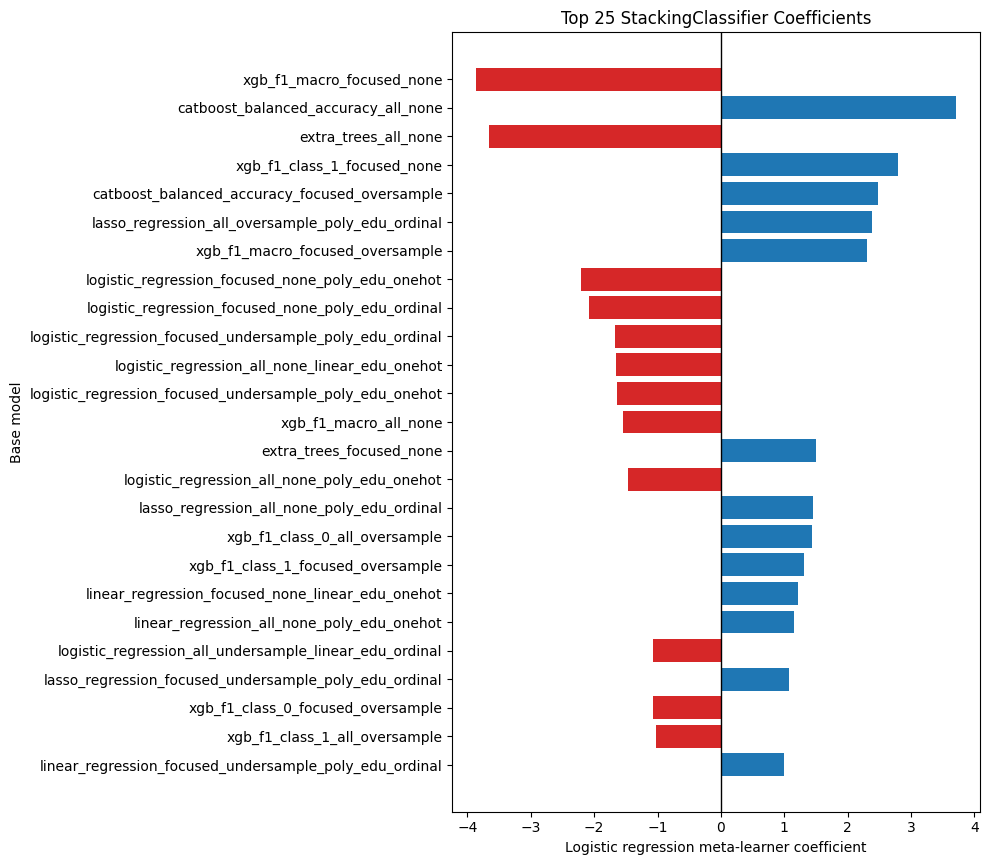

In [86]:
print("Coefficients for the entire logistic regression classifier:")
plot_stack_coefs(final_ensemble)

Coefficients for the elite Logistic Regression classifier:


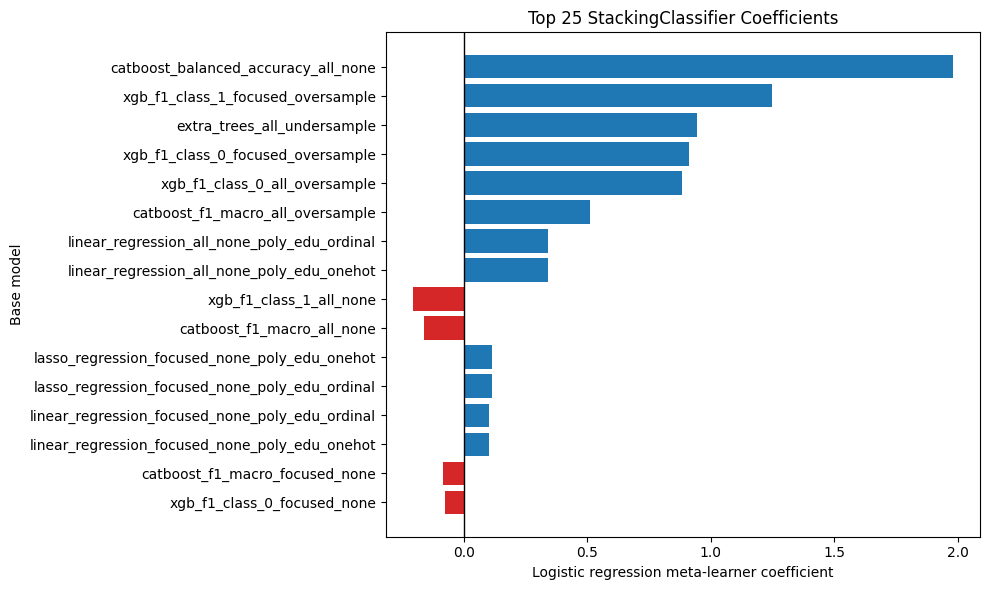

In [87]:
print("Coefficients for the elite Logistic Regression classifier:")
plot_stack_coefs(final_ensemble_elite)

Solo models sorted by balanced accuracy for the test set:

In [89]:
model_summary.sort_values("test_balanced_accuracy", ascending=False)[[
    "name",
    "family",
    "train_balanced_accuracy",
    "test_balanced_accuracy",
    "train_f1_macro",
    "test_f1_macro",
    "best_cv_score",
    "train_f1_class_1",
    "test_f1_class_1",
    "best_params",
]].head(5)

,name,family,train_balanced_accuracy,test_balanced_accuracy,train_f1_macro,test_f1_macro,best_cv_score,train_f1_class_1,test_f1_class_1,best_params
0,catboost_balanced_accuracy_all_none,catboost,0.907053,0.894205,0.773237,0.763450,0.890957,0.624767,0.607808,"{'estimator__auto_class_weights': 'Balanced', ..."
1,catboost_balanced_accuracy_all_oversample,catboost,0.903217,0.891915,0.771585,0.762966,0.889490,0.621747,0.606682,"{'estimator__auto_class_weights': None, 'estim..."
2,catboost_balanced_accuracy_all_undersample,catboost,0.897920,0.891383,0.760778,0.756333,0.888295,0.605937,0.597561,"{'estimator__auto_class_weights': None, 'estim..."
3,catboost_f1_macro_all_oversample,catboost,0.921350,0.889987,0.818267,0.795802,0.783386,0.692412,0.653266,{'estimator__base_estimator__auto_class_weight...
4,xgb_f1_class_1_all_oversample,xgboost,0.901179,0.889361,0.766623,0.759690,0.602449,0.614530,0.601684,{'estimator__base_estimator__learning_rate': 0...


Ensembles sorted by balanced accuracy for the test set:

In [100]:
display(pd.DataFrame(ensemble_comparison_rows).sort_values("test_balanced_accuracy", ascending=False))

,ensemble,test_balanced_accuracy,test_f1_macro,test_recall_class_1,test_precision_class_1
2,small_elite_xgb_stack,0.894647,0.74509,0.955163,0.419952
1,elite_logistic_stack,0.893274,0.76367,0.927989,0.452019
0,full_logistic_stack,0.892233,0.75704,0.933424,0.440667


The "elite" StackingClassifier only barely edged out the entire stacking classifier, but the xgb stacker had more improvement on the test set for `balanced_accuracy`.  The xgb ensemble beat the best solo model for balanced accuracy, jumping from `0.894205` for the `catboost_balanced_accuracy_all_none` model to `0.894647` for the `small_elite_xgb_stack`, a tiny improvement.  NOTE: Due to XGBoost and CatBoost being trained on GPU, random states and model fits aren't perfectly repeatable, so the test balanced accuracy for the stacker jumps between `.892` and `.896`.  However, the stack is hopefully more robust than a single model.

I spent wayyy more than 6-12 hours on this (the model training takes 2+ hours every time I rerun it), so hopefully my test predictions are good.  If you are reading this, I'm sorry that my notebook is so large, but I used AI to keep things concise (yet it's still so long!).  Thank you for taking the time to read through this behemoth.  

## Output predictions as a csv

In [101]:
df_test = pd.read_csv(TEST_DATA_PATH)
X_test = df_test.drop("id", axis=1)
output_preds = final_ensemble_elite_xgb.predict(X_test)
output_df = pd.DataFrame({
    "id": df_test["id"],
    "prediction": output_preds
})
output_df.to_csv("figueiredo_jaren_predictions.csv", index=False)